In [1]:
!pip install pennylane --upgrade
!pip install qutip.qip
!pip install qutip

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.0/930.0 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.1/30.1 MB 24.5 MB/s eta 0:00:00


# Otimizador de trabalho

In [2]:
import numpy as np
import pennylane as qml
from pennylane import numpy as np
from qutip import Qobj, tensor, identity, qeye, ket2dm,ptrace
import qutip as qt
from scipy.linalg import expm, sinm, cosm
from qutip_qip.operations import *
import numpy as np
from qutip import Qobj, sigmax, sigmay, sigmaz , tensor, qeye,ptrace
import matplotlib.pyplot as plt

<ipython-input-3-f5b1d3df5f59>:114: ComplexWarning: Casting complex values to real discards the imaginary part
  params[j] -= learning_rate * gradient


Epoch 1, Loss: (-0.18441839416261255+0j)
Epoch 2, Loss: (-0.18755421107744988+0j)
Epoch 3, Loss: (-0.19109508484931215+0j)
Epoch 4, Loss: (-0.19508463993988245+0j)
Epoch 5, Loss: (-0.19956925711609594+0j)
Epoch 6, Loss: (-0.20459797800816557+0j)
Epoch 7, Loss: (-0.2102224886268362+0j)
Epoch 8, Loss: (-0.21649729550614866+0j)
Epoch 9, Loss: (-0.2234802650887259+0j)
Epoch 10, Loss: (-0.23123376712035829+0j)
Epoch 11, Loss: (-0.2398267425956082+0j)
Epoch 12, Loss: (-0.24933809712992064+0j)
Epoch 13, Loss: (-0.25986188371296626+0j)
Epoch 14, Loss: (-0.2715147533518551+0j)
Epoch 15, Loss: (-0.2844460666443979+0j)
Epoch 16, Loss: (-0.29885079280659277+0j)
Epoch 17, Loss: (-0.31498475352699135+0j)
Epoch 18, Loss: (-0.3331807274773009+0j)
Epoch 19, Loss: (-0.3538622113829402+0j)
Epoch 20, Loss: (-0.3775490624912707+0j)
Epoch 21, Loss: (-0.4048458832059814+0j)
Epoch 22, Loss: (-0.4364005587181339+0j)
Epoch 23, Loss: (-0.4728188402194511+0j)
Epoch 24, Loss: (-0.5145252031041855+0j)
Epoch 25, Los

/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.11/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


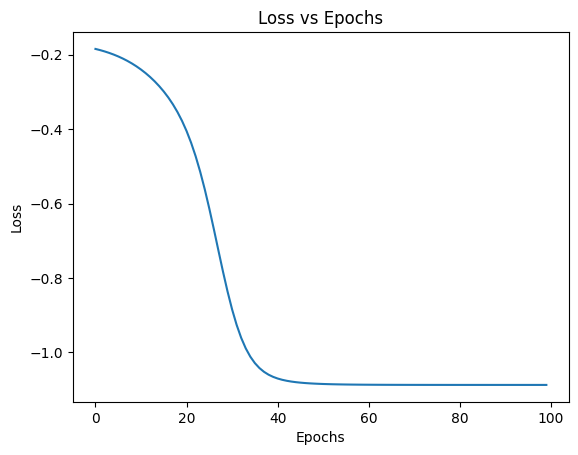

(<Figure size 500x300 with 1 Axes>, <Axes: >)

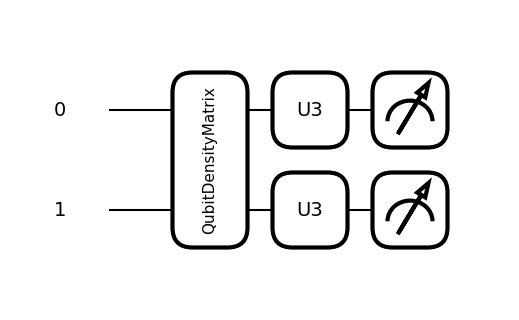

In [3]:
num_qubits = 2

dev2 = qml.device("default.mixed", wires=num_qubits)

@qml.qnode(dev2)
def circuit(x,rho):
  qml.QubitDensityMatrix(rho.full(), wires=[0,1])
  qml.U3(x[0],x[1],x[2], wires=0)
  qml.U3(x[3],x[4],x[5], wires=1)
  return qml.state()
  #otimização

import numpy as np
num_qubits = 4
dev1 = qml.device("default.qubit", wires=num_qubits)

@qml.qnode(dev1)
def term_state(num_qubits,theta_A, theta_B):
    qml.RX(theta_A, wires=0)
    qml.RX(theta_B, wires=num_qubits-1)
    for i in range(1,int(num_qubits/2)):
      qml.CNOT(wires=[0, i])
      qml.CNOT(wires=[num_qubits-1,num_qubits-(i+1) ])
    return qml.state()

@qml.qnode(dev1)
def circuito(x):
    for i in range(0,int(num_qubits/2)):
      qml.CNOT(wires=[i,num_qubits-(i+1)])
      qml.ControlledQubitUnitary(u_minus1(x[i]), control_wires=[num_qubits-(i+1)], wires=[i])
      qml.CNOT(wires=[i,num_qubits-(i+1)])
    return qml.state()




def loss1(rho0,rhof,H):
    #loss para aumentar o trabalho
    return ((rhof-rho0)*H).tr()

def rhoarhob(epsilon_b,beta_a=1, epsilon_a=1, beta_b=2):
    #hamiltoniana
    sz=np.array([[1, 0], [0, -1]])
    H_A = -0.5 * epsilon_a * sz
    H_B = -0.5 * epsilon_b * sz

    # traço
    Z_a = np.trace(expm(-beta_a * H_A))
    Z_b = np.trace(expm(-beta_b * H_B))

    pa, pb, alpha=np.exp(-beta_a*epsilon_a)/Z_a,np.exp(-beta_b*epsilon_b)/Z_b,1/(Z_a*Z_b)

    element_00 = pa * pb - alpha**2
    element_11 = alpha**2 + pa * (1-pb)
    element_22 = alpha**2 +pb*(1-pa)
    element_33 = (1 - pa) * (1 - pb) - alpha**2

    matrix = np.array([
        [element_00, 0, 0, 0],
        [0, element_11, alpha, 0],
        [0, alpha, element_22, 0],
        [0, 0, 0, element_33]
    ])

    return qt.Qobj(matrix,dims=[[2,2],[2,2]])

def loss_function(params):
    """
    Função de perda a ser minimizada.
    Substitua por sua própria função de perda.
    """
    num_qubits = 2
    #rho_ab
    eb=0.5
    rho = rhoarhob(eb,2)
    #psi_ab
    parametros = params # Valores de exemplo para os parâmetros
    state = Qobj(circuit(parametros,rho),dims=cnot(num_qubits,0,1).dims)
    #função
    rho0 = rho # Operador densidade inicial
    rhof = state*state.dag()# operador densidade final
    H=tensor(-sigmaz()*0.5,qeye(2))+tensor(qeye(2),-sigmaz()*0.5*eb)

    return loss1(rho0,rhof,H)

def parameter_shift_gradient(params, j):
    """
    Calcula o gradiente da função de perda em relação ao parâmetro j
    usando a regra parameter-shift.
    """
    epsilon=0.05
    shifted_params_plus = params.copy()
    shifted_params_plus[j] += epsilon

    shifted_params_minus = params.copy()
    shifted_params_minus[j] -= epsilon

    gradient = (loss_function(shifted_params_plus) - loss_function(shifted_params_minus))/(2*epsilon)
    #print(gradient,loss_function(shifted_params_plus),loss_function(shifted_params_minus))
    return gradient

def stochastic_gradient_descent(params, learning_rate, num_epochs,epsilon):
    """
    Executa o algoritmo SGD usando a regra parameter-shift para calcular gradientes.
    """
    epoch=0
    loss=0
    loss_vec=[]
    epochs_vec=[]
    while ( epoch<num_epochs):#np.real(loss)>(-epsilon) and

      for j in range(len(params)):
          gradient = parameter_shift_gradient(params, j)
          params[j] -= learning_rate * gradient

      # Avalie a função de perda após cada época, se desejar
      loss = loss_function(params)
      loss_vec.append(loss)
      epochs_vec.append(epoch)
      print(f"Epoch {epoch+1}, Loss: {loss}")
      epoch+=1
    return params,loss_vec,epochs_vec

# Exemplo de uso
params = np.random.rand(6)  # Inicialize os parâmetros aleatoriamente
learning_rate = 0.5
num_epochs = 100

optimized_params,vec1,vec2 = stochastic_gradient_descent(params, learning_rate,num_epochs,0.1)
print(optimized_params)
-
plt.plot(vec2,vec1)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss vs Epochs')
plt.show()
qml.draw_mpl(circuit)(optimized_params,rhoarhob(0.5))

<ipython-input-14-cb8c9df765b5>:113: ComplexWarning: Casting complex values to real discards the imaginary part
  params[j] += learning_rate * gradient


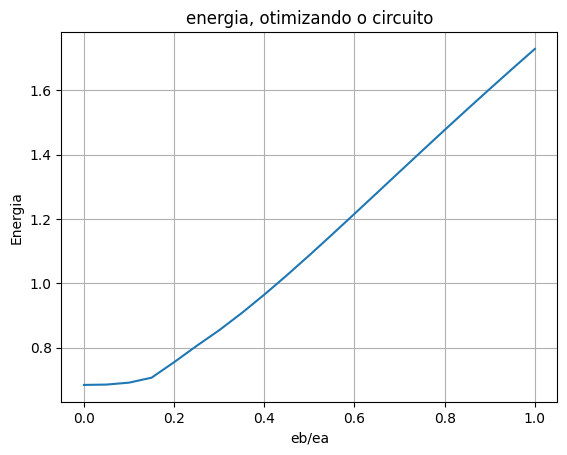

(<Figure size 500x300 with 1 Axes>, <Axes: >)

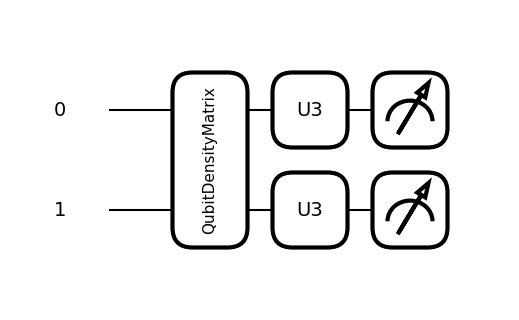

In [ ]:
num_qubits = 2

dev2 = qml.device("default.mixed", wires=num_qubits)

@qml.qnode(dev2)
def circuit(x,rho):
  qml.QubitDensityMatrix(rho.full(), wires=[0,1])
  qml.U3(x[0],x[1],x[2], wires=0)
  qml.U3(x[3],x[4],x[5], wires=1)
  return qml.state()
  #otimização

import numpy as np
num_qubits = 4
dev1 = qml.device("default.qubit", wires=num_qubits)

@qml.qnode(dev1)
def term_state(num_qubits,theta_A, theta_B):
    qml.RX(theta_A, wires=0)
    qml.RX(theta_B, wires=num_qubits-1)
    for i in range(1,int(num_qubits/2)):
      qml.CNOT(wires=[0, i])
      qml.CNOT(wires=[num_qubits-1,num_qubits-(i+1) ])
    return qml.state()

@qml.qnode(dev1)
def circuito(x):
    for i in range(0,int(num_qubits/2)):
      qml.CNOT(wires=[i,num_qubits-(i+1)])
      qml.ControlledQubitUnitary(u_minus1(x[i]), control_wires=[num_qubits-(i+1)], wires=[i])
      qml.CNOT(wires=[i,num_qubits-(i+1)])
    return qml.state()




def loss1(rho0,rhof,H):
    #loss para aumentar o trabalho
    return -((rhof-rho0)*H).tr()

def rhoarhob(epsilon_b,beta_a=1, epsilon_a=1, beta_b=2):
    #hamiltoniana
    sz=np.array([[1, 0], [0, -1]])
    H_A = -0.5 * epsilon_a * sz
    H_B = -0.5 * epsilon_b * sz

    # traço
    Z_a = np.trace(expm(-beta_a * H_A))
    Z_b = np.trace(expm(-beta_b * H_B))

    pa, pb, alpha=np.exp(-beta_a*epsilon_a)/Z_a,np.exp(-beta_b*epsilon_b)/Z_b,1/(Z_a*Z_b)

    element_00 = pa * pb - alpha**2
    element_11 = alpha**2 + pa * (1-pb)
    element_22 = alpha**2 +pb*(1-pa)
    element_33 = (1 - pa) * (1 - pb) - alpha**2

    matrix = np.array([
        [element_00, 0, 0, 0],
        [0, element_11, alpha, 0],
        [0, alpha, element_22, 0],
        [0, 0, 0, element_33]
    ])

    return qt.Qobj(matrix,dims=[[2,2],[2,2]])

def loss_function(params,eb):
    """
    Função de perda a ser minimizada.
    Substitua por sua própria função de perda.
    """
    num_qubits = 2
    #rho_ab
    rho = rhoarhob(eb,2)
    #psi_ab
    parametros = params # Valores de exemplo para os parâmetros
    state = Qobj(circuit(parametros,rho),dims=cnot(num_qubits,0,1).dims)
    #função
    rho0 = rho # Operador densidade inicial
    rhof = state*state.dag()# operador densidade final
    H=tensor(-sigmaz()*0.5,qeye(2))+tensor(qeye(2),-sigmaz()*0.5*eb)

    return loss1(rho0,rhof,H)

def parameter_shift_gradient(params, j,eb):
    """
    Calcula o gradiente da função de perda em relação ao parâmetro j
    usando a regra parameter-shift.
    """
    epsilon=0.05
    shifted_params_plus = params.copy()
    shifted_params_plus[j] += epsilon

    shifted_params_minus = params.copy()
    shifted_params_minus[j] -= epsilon

    gradient = (loss_function(shifted_params_plus,eb) - loss_function(shifted_params_minus,eb))/(2*epsilon)
    #print(gradient,loss_function(shifted_params_plus),loss_function(shifted_params_minus))
    return gradient

def stochastic_gradient_descent(params, learning_rate, num_epochs,eb):
    """
    Executa o algoritmo SGD usando a regra parameter-shift para calcular gradientes.
    """
    epoch=0
    loss=0
    loss_vec=[]
    epochs_vec=[]
    while ( epoch<num_epochs):#np.real(loss)>(-epsilon) and

      for j in range(len(params)):
          gradient = parameter_shift_gradient(params, j,eb)
          params[j] += learning_rate * gradient

      # Avalie a função de perda após cada época, se desejar
      loss = loss_function(params,eb)
      #loss_vec.append(loss)
      #epochs_vec.append(epoch)
      #print(f"Epoch {epoch+1}, Loss: {loss}")
      epoch+=1
    return loss

# Exemplo de uso
params = np.random.rand(6)  # Inicialize os parâmetros aleatoriamente
learning_rate = 0.5
num_epochs = 100
ener=np.linspace(0,1,21)
optimized_params=np.zeros(len(ener))
loss_vec=np.zeros(len(ener))

for i,eb in enumerate(ener):
  loss_vec[i] = np.real(stochastic_gradient_descent(params, learning_rate,num_epochs,eb))
plt.plot(ener,loss_vec)
plt.xlabel('eb/ea')
plt.ylabel('Energia')
plt.title('energia, otimizando o circuito')
plt.grid(True)
plt.show()
qml.draw_mpl(circuit)(optimized_params,rhoarhob(0.5))

In [ ]:
import numpy as np

def u3_gate(theta, phi, lambda_):
  """
  Cria a matriz do gate U3 no NumPy.

  Args:
      theta: Ângulo de rotação theta (em radianos).
      phi: Ângulo de rotação phi (em radianos).
      lambda_: Ângulo de rotação lambda (em radianos).

  Returns:
      np.ndarray: A matriz 2x2 que representa o gate U3.
  """

  cos_half_theta = np.cos(theta / 2)
  sin_half_theta = np.sin(theta / 2)

  return np.array([
      [cos_half_theta, -np.exp(1j * lambda_) * sin_half_theta],
      [np.exp(1j * phi) * sin_half_theta, np.exp(1j * (phi + lambda_)) * cos_half_theta]
  ])

# Exemplo de uso
theta = np.pi / 4  # 45 graus
phi = np.pi / 2    # 90 graus
lambda_ = np.pi     # 180 graus

u3_matrix = u3_gate(3.14151539,0.08718484,0.51252627)
print(u3_matrix)
u3_matrix = u3_gate(0.27990093,0.65937876,0.12316665)
print(u3_matrix)

[[ 3.86317949e-05+0.00000000e+00j -8.71508456e-01-4.90380475e-01j]
 [ 9.96201808e-01+8.70744304e-02j  3.18904965e-05+2.18039403e-05j]]
[[ 0.99022291+0.j         -0.13843734-0.01713761j]
 [ 0.11025234+0.08545768j  0.70218796+0.69819301j]]


# Estado X

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[ 0.22330494  0.          0.          0.26702917]
 [ 0.          0.11177397 -0.09332999  0.        ]
 [ 0.         -0.09332999  0.19720032  0.        ]
 [ 0.26702917  0.          0.          0.46772078]]


(<Figure size 1200x500 with 1 Axes>, <Axes: >)

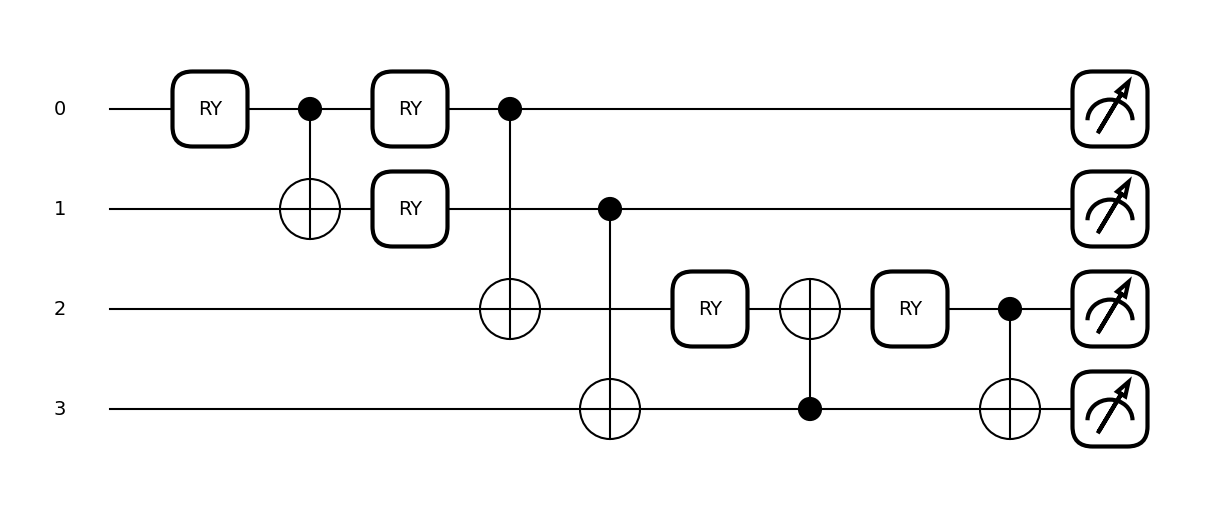

In [ ]:
import pennylane as qml
from pennylane import numpy as np

# Assuming you have angles alpha, beta, gamma, theta, and phi defined

dev = qml.device("default.qubit", wires=4)  # 4 qubits

@qml.qnode(dev)
def X_state(alpha, beta, gamma, theta, phi):
    qml.RY(alpha, wires=0)
    qml.CNOT(wires=[0, 1])
    qml.RY(beta, wires=0)
    qml.RY(gamma, wires=1)
    qml.CNOT(wires=[0, 2])
    qml.CNOT(wires=[1, 3])
    qml.RY(theta + phi, wires=2)
    qml.CNOT(wires=[3, 2])
    qml.RY(theta - phi, wires=2)
    qml.CNOT(wires=[2,3])
    return qml.state()

# Execute the circuit (replace with your actual angle values)
alpha, beta, gamma, theta, phi=np.pi/4,1,1,1,1
result =X_state(alpha, beta, gamma, theta, phi)
rho=Qobj(np.outer(result,np.conjugate(result)),dims=cnot(4,0,1).dims)
print(ptrace(rho,[2,3]))
qml.draw_mpl(X_state)(1,1,1,1,1)